<a href="https://colab.research.google.com/github/ab1991sharma/quantum_study/blob/main/sept_cohort_session_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install qiskit qiskit-aer pylatexenc matplotlib ipywidgets

Program 1: Gate Combination Explorer

This program demonstrates how multiple quantum gates can be applied sequentially to a single qubit and how each gate contributes to the final quantum state.

The circuit starts with one qubit in the state |0⟩ and applies three gates in sequence:

H → Z → X

H (Hadamard) creates a superposition of |0⟩ and |1⟩.
Z (Pauli-Z) changes the phase of the |1⟩ component.
X (Pauli-X) flips |0⟩ and |1⟩.

After applying these gates, the program examines the resulting qubit in three different ways:

Quantum circuit diagram — shows the sequence of gates applied.
Statevector — shows the mathematical representation of the final quantum state.
Bloch sphere — provides a graphical representation of the qubit's final state.

Finally, the program calculates the probability of measuring |0⟩ and |1⟩ and displays those probabilities as a bar chart.

This allows us to connect the theory of quantum gates with their visual and numerical representations, helping us understand how a sequence of gates transforms a qubit.

Quantum Circuit:


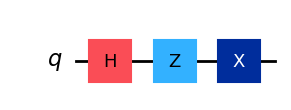


Final State:
Statevector([-0.70710678+0.j,  0.70710678+0.j],
            dims=(2,))

Bloch Sphere:


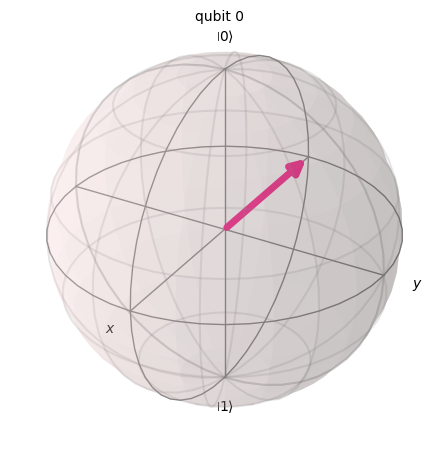


Measurement Probabilities:
P(|0⟩) = 0.5000
P(|1⟩) = 0.5000


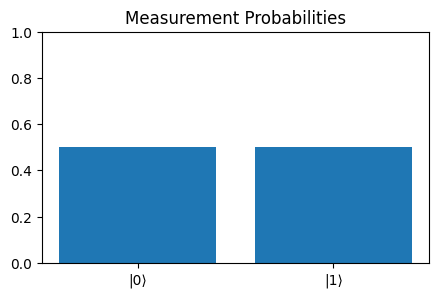

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display


# Create a one-qubit circuit
qc = QuantumCircuit(1)

# Apply multiple gates
qc.h(0)
qc.z(0)
qc.x(0)

# Display the circuit
print("Quantum Circuit:")
display(qc.draw("mpl"))

# Calculate final state
state = Statevector.from_instruction(qc)

print("\nFinal State:")
print(state)

# Display Bloch Sphere
print("\nBloch Sphere:")
display(plot_bloch_multivector(state))

# Display measurement probabilities
probs = state.probabilities()

print("\nMeasurement Probabilities:")
print(f"P(|0⟩) = {probs[0]:.4f}")
print(f"P(|1⟩) = {probs[1]:.4f}")

plt.figure(figsize=(5, 3))
plt.bar(["|0⟩", "|1⟩"], probs)
plt.ylim(0, 1)
plt.title("Measurement Probabilities")
plt.show()

Program 2 – Quantum Gate Order Experiment
Concept

Does the order of quantum gates matter?

In classical computing, we often expect operations to behave predictably when rearranged. In quantum computing, however, the order of operations can change the final quantum state.

This program compares two circuits that use the same gates but in different orders:

Circuit A:  H → X
Circuit B:  X → H

Students can observe that changing the order of the gates can produce different final states.

What the program will demonstrate
Creating multiple quantum circuits
Applying the same gates in different orders
Visualizing both circuits
Calculating their final statevectors
Comparing measurement probabilities
Understanding that quantum gates generally do not commute

Circuit A: H → X


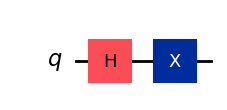

Final State:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Circuit B: X → H


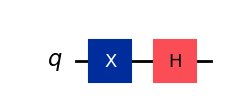

Final State:
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

Measurement Probabilities
Circuit A (H → X):
P(|0⟩) = 0.50
P(|1⟩) = 0.50

Circuit B (X → H):
P(|0⟩) = 0.50
P(|1⟩) = 0.50


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display

# -----------------------------
# Circuit A: H → X
# -----------------------------
qc_a = QuantumCircuit(1)

qc_a.h(0)
qc_a.x(0)

# Calculate final state
state_a = Statevector.from_instruction(qc_a)

# -----------------------------
# Circuit B: X → H
# -----------------------------
qc_b = QuantumCircuit(1)

qc_b.x(0)
qc_b.h(0)

# Calculate final state
state_b = Statevector.from_instruction(qc_b)

# -----------------------------
# Display Circuit A
# -----------------------------
print("Circuit A: H → X")
display(qc_a.draw("mpl"))

print("Final State:")
print(state_a)

# -----------------------------
# Display Circuit B
# -----------------------------
print("\nCircuit B: X → H")
display(qc_b.draw("mpl"))

print("Final State:")
print(state_b)

# -----------------------------
# Measurement Probabilities
# -----------------------------
probs_a = state_a.probabilities()
probs_b = state_b.probabilities()

print("\nMeasurement Probabilities")

print("Circuit A (H → X):")
print(f"P(|0⟩) = {probs_a[0]:.2f}")
print(f"P(|1⟩) = {probs_a[1]:.2f}")

print("\nCircuit B (X → H):")
print(f"P(|0⟩) = {probs_b[0]:.2f}")
print(f"P(|1⟩) = {probs_b[1]:.2f}")

Program 3 – Two-Qubit Gate Laboratory
Objective

This program introduces multi-qubit quantum circuits and demonstrates how two qubits can interact using a CNOT (Controlled-NOT) gate.

We will first create two independent qubits and then use a Hadamard gate followed by a CNOT gate to create an entangled Bell state.

The circuit will demonstrate the following sequence:

q₀: ── H ──●──
           │
q₁: ───────X──

The Hadamard gate places the first qubit into a superposition, while the CNOT gate uses the first qubit as the control and the second qubit as the target.

The resulting state is:

|Φ⁺⟩ = (|00⟩ + |11⟩) / √2

When the two qubits are measured, we should observe 00 or 11, but not 01 or 10. This demonstrates the correlation between entangled qubits.

Quantum Circuit:


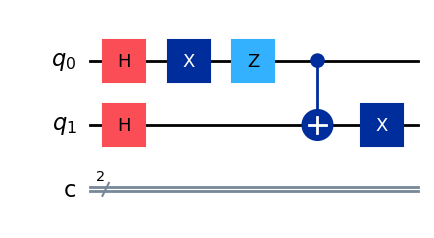


Final State:
Statevector([ 0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))

Measurement Results:
{'01': 237, '11': 272, '00': 246, '10': 245}


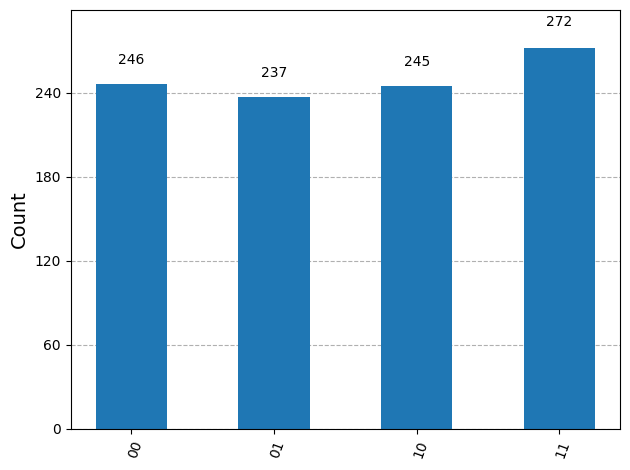

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from IPython.display import display

# Create a simulator
simulator = AerSimulator()

# Create a two-qubit circuit with two classical bits
qc = QuantumCircuit(2, 2)

# Apply gates to the first qubit
qc.h(0)
qc.x(0)
qc.z(0)

# Apply a Hadamard gate to the second qubit
qc.h(1)

# Create interaction between the two qubits
qc.cx(0, 1)

# Apply another gate after the CNOT
qc.x(1)

# Display the circuit
print("Quantum Circuit:")
display(qc.draw("mpl"))

# Calculate the final statevector
state = Statevector.from_instruction(qc)

print("\nFinal State:")
print(state)

# Add measurement
qc.measure([0, 1], [0, 1])

# Run the circuit
job = simulator.run(qc, shots=1000)

# Get results
result = job.result()
counts = result.get_counts()

# Display measurement results
print("\nMeasurement Results:")
print(counts)

# Display histogram
display(plot_histogram(counts))

Program 4 – Quantum Circuit Challenge
Objective

This program turns the concepts from the previous demonstrations into a small prediction-based exercise.

Instead of immediately looking at the result of a quantum circuit, students are given a circuit containing a sequence of quantum gates and are asked to predict the final state and measurement probabilities before running it.

The program uses a simple single-qubit circuit with multiple gates. Students can first work through the circuit manually and then execute the code to check whether their prediction is correct.

This reinforces an important skill in quantum programming:

Before running a quantum circuit, we should be able to reason about how each gate transforms the quantum state.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Create a one-qubit circuit
qc = QuantumCircuit(1, 1)

# Apply a sequence of gates
qc.h(0)
qc.z(0)
qc.h(0)
qc.x(0)

# Display the circuit
print("Quantum Circuit:")
print(qc.draw())

# Calculate the final statevector
state = Statevector.from_instruction(qc)

print("\nFinal State:")
print(state)

# Calculate measurement probabilities
probs = state.probabilities()

print("\nMeasurement Probabilities:")
print(f"P(|0⟩) = {probs[0]:.2f}")
print(f"P(|1⟩) = {probs[1]:.2f}")

# Add measurement
qc.measure(0, 0)

# Display the final circuit
print("\nCircuit with Measurement:")
print(qc.draw())

Quantum Circuit:
     ┌───┐┌───┐┌───┐┌───┐
  q: ┤ H ├┤ Z ├┤ H ├┤ X ├
     └───┘└───┘└───┘└───┘
c: 1/════════════════════
                         

Final State:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Measurement Probabilities:
P(|0⟩) = 1.00
P(|1⟩) = 0.00

Circuit with Measurement:
     ┌───┐┌───┐┌───┐┌───┐┌─┐
  q: ┤ H ├┤ Z ├┤ H ├┤ X ├┤M├
     └───┘└───┘└───┘└───┘└╥┘
c: 1/═════════════════════╩═
                          0 


Program 5 – Quantum Random Number Generator
Objective

This program demonstrates a simple real-world application of quantum measurement: generating random numbers using a quantum circuit.

A classical computer normally generates random-looking numbers using pseudo-random algorithms, where the result is produced by a deterministic process. A quantum system, however, can produce genuinely probabilistic measurement outcomes.

In this program, we use a Hadamard gate to put a qubit into an equal superposition of |0⟩ and |1⟩:

|0⟩ → (|0⟩ + |1⟩) / √2

When the qubit is measured, there is a 50% probability of obtaining 0 and a 50% probability of obtaining 1.

We repeat this process several times to generate a sequence of random binary values. The binary values can then be combined to create a random number.

For example:

10110101

is an 8-bit random binary number.

This program connects the quantum concepts of superposition and measurement to a practical application: quantum random number generation (QRNG).

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Create the simulator
simulator = AerSimulator()

# Number of random bits to generate
num_bits = 8

# Create the quantum circuit
qc = QuantumCircuit(num_bits, num_bits)

# Put every qubit into superposition
for qubit in range(num_bits):
    qc.h(qubit)

# Measure every qubit
qc.measure(range(num_bits), range(num_bits))

# Display the circuit
print("Quantum Random Number Generator Circuit:")
print(qc.draw())

# Run the circuit once
result = simulator.run(qc, shots=1).result()

# Get the random bit string
counts = result.get_counts()
random_bits = list(counts.keys())[0]

# Convert binary to decimal
random_number = int(random_bits, 2)

print("\nRandom Binary Number:")
print(random_bits)

print("\nRandom Decimal Number:")
print(random_number)

Quantum Random Number Generator Circuit:
     ┌───┐┌─┐                     
q_0: ┤ H ├┤M├─────────────────────
     ├───┤└╥┘┌─┐                  
q_1: ┤ H ├─╫─┤M├──────────────────
     ├───┤ ║ └╥┘┌─┐               
q_2: ┤ H ├─╫──╫─┤M├───────────────
     ├───┤ ║  ║ └╥┘┌─┐            
q_3: ┤ H ├─╫──╫──╫─┤M├────────────
     ├───┤ ║  ║  ║ └╥┘┌─┐         
q_4: ┤ H ├─╫──╫──╫──╫─┤M├─────────
     ├───┤ ║  ║  ║  ║ └╥┘┌─┐      
q_5: ┤ H ├─╫──╫──╫──╫──╫─┤M├──────
     ├───┤ ║  ║  ║  ║  ║ └╥┘┌─┐   
q_6: ┤ H ├─╫──╫──╫──╫──╫──╫─┤M├───
     ├───┤ ║  ║  ║  ║  ║  ║ └╥┘┌─┐
q_7: ┤ H ├─╫──╫──╫──╫──╫──╫──╫─┤M├
     └───┘ ║  ║  ║  ║  ║  ║  ║ └╥┘
c: 8/══════╩══╩══╩══╩══╩══╩══╩══╩═
           0  1  2  3  4  5  6  7 

Random Binary Number:
01100000

Random Decimal Number:
96
